# Adaptive-compute analysis across SlotODE configs

For each of the 8 SlotODE checkpoints (`T \in {3,4,5,6}`, `\Delta t \in {1, 0.5}`), run inference with two adaptive solvers (`Dopri5` and `Tsit5`) at fixed tolerances, integrate from $t = 0$ to $t = T_{\text{train}}$, and record per-image step count. Group by ground-truth object count to produce a table of mean steps per (model, solver, n_objects).

Both Dopri5 and Tsit5 are 5th-order with 6 effective stages, so step count is directly proportional to NFE. We report **steps** (`sol.stats['num_steps']`) — the step count is a fair proxy for compute across same-order solvers, and the absolute NFE = `6 * steps` for both.

In [41]:
import pickle
from pathlib import Path
import time

import jax
jax.config.update("jax_default_matmul_precision", "highest")
import jax.numpy as jnp
import equinox as eqx
import numpy as np
import diffrax
from PIL import Image
import pandas as pd

from model import SlotODEModel

In [42]:
DATA_DIR = Path("CLEVR_64")
RESOLUTION = (64, 64)
N_EVAL = 500          # val images per (model, solver) cell
RTOL = 1e-3
ATOL = 1e-4
INIT_SEED = 42

MODELS = [
    ("T=3 dt=1",   "runs_data/omkos-slotode/slot_ode_11_slots_euler_T3_dt1/checkpoints/best.eqx"),
    ("T=3 dt=0.5", "runs_data/omkos-slotode/slot_ode_11_slots_euler_T3_dt0.5/checkpoints/best.eqx"),
    ("T=4 dt=1",   "runs_data/omkos-slotode/slot_ode_11_slots_euler_T4_dt1/checkpoints/best.eqx"),
    ("T=4 dt=0.5", "runs_data/omkos-slotode/slot_ode_11_slots_euler_T4_dt0.5/checkpoints/best.eqx"),
    ("T=5 dt=1",   "runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt1/checkpoints/best.eqx"),
    ("T=5 dt=0.5", "runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt0.5/checkpoints/best.eqx"),
    ("T=6 dt=1",   "runs_data/omkos-slotode/slot_ode_11_slots_euler_T6_dt1/checkpoints/best.eqx"),
    ("T=6 dt=0.5", "runs_data/omkos-slotode/slot_ode_11_slots_euler_T6_dt0.5/checkpoints/best.eqx"),
]

SOLVERS = {
    "Dopri5": diffrax.Dopri5(),
    "Tsit5":  diffrax.Tsit5(),
}

## 1. Load val data + object counts

In [43]:
def load_val(data_dir, n):
    img_dir = data_dir / "images" / "val"
    vis_dir = data_dir / "visibility" / "val"
    images, n_objs = [], []
    for ip in sorted(img_dir.glob("*.png"))[:n]:
        vp = vis_dir / f"{ip.stem}.npy"
        if not vp.exists():
            continue
        img = np.array(Image.open(ip).convert("RGB"), dtype=np.float32) / 127.5 - 1.0
        images.append(np.transpose(img, (2, 0, 1)))
        vis = np.load(vp)
        n_objs.append(int((vis[1:] > 0.5).sum()))
    return np.stack(images), np.array(n_objs)

images_np, obj_counts = load_val(DATA_DIR, N_EVAL)
print(f"loaded {len(images_np)} images")
uniq, cnts = np.unique(obj_counts, return_counts=True)
print("object-count distribution:")
for u, c in zip(uniq, cnts):
    print(f"  {u} objects: {c} scenes")

loaded 500 images
object-count distribution:
  3 objects: 62 scenes
  4 objects: 59 scenes
  5 objects: 69 scenes
  6 objects: 62 scenes
  7 objects: 71 scenes
  8 objects: 63 scenes
  9 objects: 65 scenes
  10 objects: 49 scenes


## 2. Helpers — encode scene, run adaptive solver

In [44]:
def load_model(ckpt_path, key):
    meta = pickle.load(open(ckpt_path.replace(".eqx", "_meta.pkl"), "rb"))
    a = meta["args"]
    model = SlotODEModel(
        resolution=RESOLUTION,
        num_slots=a["num_slots"], slot_dim=a["slot_dim"],
        enc_hidden_dim=a.get("enc_hidden_dim", 64),
        num_iter=a["num_iter"], dt0=a.get("dt", None) or 1.0,
        key=key,
    )
    model = eqx.tree_deserialise_leaves(ckpt_path, model)
    return model, a

def make_runner(model, solver, T_train):
    """Returns a JIT'd fn: image [3,H,W] -> num_steps (int)."""
    sa = model.slot_attention_ode
    enc = model.enc

    @eqx.filter_jit
    def run_one(image, init_key):
        img_b = image[None]
        feat = enc(img_b)
        feat_norm = jax.vmap(jax.vmap(sa.norm_input))(feat)
        feat_proj = jax.vmap(jax.vmap(sa.fc_input))(feat_norm)
        k = jax.vmap(jax.vmap(sa.to_k))(feat_proj)
        v = jax.vmap(jax.vmap(sa.to_v))(feat_proj)
        slots_0 = sa.initialize_slots(1, init_key)

        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(sa.slot_ode_func),
            solver,
            t0=0.0, t1=T_train, dt0=0.1, y0=slots_0, args=(k, v),
            saveat=diffrax.SaveAt(t1=True),
            stepsize_controller=diffrax.PIDController(rtol=RTOL, atol=ATOL),
            max_steps=4096,
        )
        return sol.stats["num_steps"]

    return run_one

## 3. Run sweep

In [45]:
import os

RECORDS_PATH = "adaptive_compute_records.csv"
FORCE_RERUN = False  # set True to redo the sweep regardless of cached CSV

if os.path.exists(RECORDS_PATH) and not FORCE_RERUN:
    df = pd.read_csv(RECORDS_PATH)
    print(f"loaded cached records from {RECORDS_PATH}: {len(df)} rows")
    print(df.groupby(['model', 'solver']).size().to_string())
else:
    # need val data for the sweep — load if not already in scope
    if "images_np" not in dir():
        images_np, obj_counts = load_val(DATA_DIR, N_EVAL)
        print(f"loaded {len(images_np)} images for sweep")

    records = []  # (model_label, solver, n_obj, steps)
    init_key = jax.random.key(INIT_SEED)
    for label, ckpt in MODELS:
        print(f"== {label} ==  loading...")
        key0, init_key = jax.random.split(init_key)
        model, args = load_model(ckpt, key0)
        T_train = float(args["num_iter"])

        for solver_name, solver in SOLVERS.items():
            run_one = make_runner(model, solver, T_train)
            _ = run_one(jnp.array(images_np[0]), jax.random.key(INIT_SEED))  # warmup
            t0 = time.time()
            for i in range(len(images_np)):
                ns = int(run_one(jnp.array(images_np[i]), jax.random.key(INIT_SEED)))
                records.append((label, solver_name, int(obj_counts[i]), ns))
            print(f"  {solver_name}: {len(images_np)} imgs in {time.time() - t0:.1f}s")
        del model

    df = pd.DataFrame(records, columns=["model", "solver", "n_obj", "steps"])
    df.to_csv(RECORDS_PATH, index=False)
    print(f"\nwrote {RECORDS_PATH}: {len(df)} rows")

loaded cached records from adaptive_compute_records.csv: 8000 rows
model       solver
T=3 dt=0.5  Dopri5    500
            Tsit5     500
T=3 dt=1    Dopri5    500
            Tsit5     500
T=4 dt=0.5  Dopri5    500
            Tsit5     500
T=4 dt=1    Dopri5    500
            Tsit5     500
T=5 dt=0.5  Dopri5    500
            Tsit5     500
T=5 dt=1    Dopri5    500
            Tsit5     500
T=6 dt=0.5  Dopri5    500
            Tsit5     500
T=6 dt=1    Dopri5    500
            Tsit5     500


## 4. Aggregate table — mean steps per (model, solver, n_obj)

In [46]:
df.to_csv("adaptive_compute_records.csv", index=False)

# pivot: rows = (model, solver), cols = n_obj, values = mean steps
pivot = df.groupby(["model", "solver", "n_obj"])["steps"].mean().reset_index()
table = pivot.pivot_table(index=["model", "solver"], columns="n_obj", values="steps")
table["overall"] = df.groupby(["model", "solver"])["steps"].mean()

print("Mean adaptive steps by scene object count")
print("(NFE = 6 * steps for both Dopri5 and Tsit5)\n")
print(table.round(2).to_string())

table.to_csv("adaptive_compute_table.csv")

Mean adaptive steps by scene object count
(NFE = 6 * steps for both Dopri5 and Tsit5)

n_obj                  3      4      5      6      7      8      9     10  overall
model      solver                                                                 
T=3 dt=0.5 Dopri5  13.61  14.73  15.51  16.71  18.21  19.76  19.98  20.73    17.34
           Tsit5   15.32  16.78  17.49  18.98  21.13  22.78  23.62  24.63    20.00
T=3 dt=1   Dopri5   7.90   8.73   9.55   9.82  11.14  11.49  12.26  12.20    10.37
           Tsit5    8.98  10.12  11.71  12.53  13.59  15.25  15.11  14.76    12.74
T=4 dt=0.5 Dopri5  18.97  20.63  22.10  21.87  23.07  23.62  23.48  24.80    22.28
           Tsit5   21.35  22.83  24.46  24.61  25.89  25.54  27.06  27.45    24.87
T=4 dt=1   Dopri5   9.37   9.69  10.64  10.97  11.66  12.37  12.57  13.35    11.29
           Tsit5   10.71  11.31  12.74  12.92  14.63  15.75  15.77  16.59    13.76
T=5 dt=0.5 Dopri5  36.58  39.85  41.36  42.45  43.20  44.86  45.43  44.80    42.29


In [47]:
# also: standard deviation table for context on variability
std_pivot = df.groupby(["model", "solver", "n_obj"])["steps"].std().reset_index()
std_table = std_pivot.pivot_table(index=["model", "solver"], columns="n_obj", values="steps")
std_table["overall"] = df.groupby(["model", "solver"])["steps"].std()

print("Std-dev of adaptive steps by scene object count\n")
print(std_table.round(2).to_string())

Std-dev of adaptive steps by scene object count

n_obj                  3     4     5     6     7     8     9    10  overall
model      solver                                                          
T=3 dt=0.5 Dopri5   3.50  3.62  3.94  4.46  4.75  4.50  4.60  4.24     4.86
           Tsit5    3.37  3.97  4.25  3.90  4.96  4.52  4.08  4.56     5.25
T=3 dt=1   Dopri5   1.53  2.00  1.93  2.28  2.28  2.69  2.50  2.35     2.67
           Tsit5    1.95  2.63  2.82  3.32  2.92  3.24  2.57  3.02     3.56
T=4 dt=0.5 Dopri5   4.28  4.79  4.76  4.63  4.75  3.79  3.94  4.29     4.71
           Tsit5    4.89  4.85  4.96  4.02  4.37  3.79  4.11  3.95     4.76
T=4 dt=1   Dopri5   1.39  1.15  1.43  1.48  1.83  1.81  1.69  1.93     2.04
           Tsit5    2.16  1.83  2.39  2.07  2.58  3.01  2.60  2.86     3.16
T=5 dt=0.5 Dopri5   9.72  8.92  7.27  7.63  7.38  7.58  7.12  7.59     8.35
           Tsit5   10.31  9.23  7.68  7.20  9.10  8.27  6.60  8.04     8.98
T=5 dt=1   Dopri5   1.07  1.26  1.61  1

## 5. Plots — dt=1 family

Main plot: mean Dopri5 steps vs scene object count, one curve per $T \in \{3,4,5,6\}$ (all $\Delta t = 1$). The $\Delta t = 0.5$ family is omitted from the main plots (it remains in the appendix table). Secondary plot overlays Dopri5 and Tsit5 to show the trend isn't solver-specific.

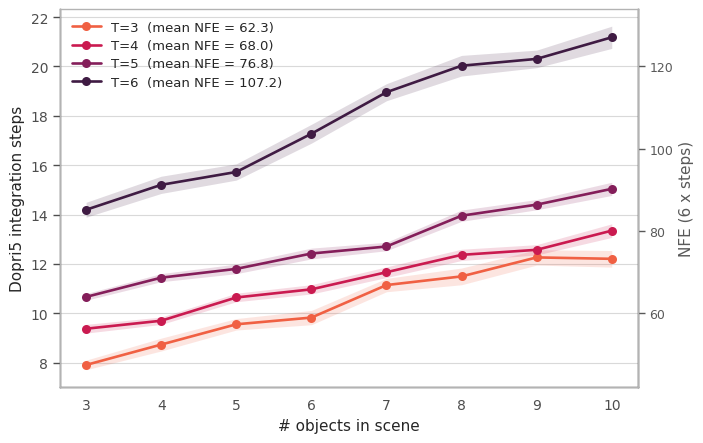

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white", context="paper", font_scale=1.25)

DT1_MODELS = ["T=3 dt=1", "T=4 dt=1", "T=5 dt=1", "T=6 dt=1"]
T_COLORS = dict(zip(DT1_MODELS, sns.color_palette("rocket_r", n_colors=len(DT1_MODELS) + 1)[1:]))

def curve(df_sub):
    g = df_sub.groupby("n_obj")["steps"]
    n = sorted(g.groups.keys())
    return (np.array(n),
            np.array([g.get_group(k).mean() for k in n]),
            np.array([g.get_group(k).std() for k in n]),
            np.array([g.get_group(k).count() for k in n]))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for m in DT1_MODELS:
    sub = df[(df["model"] == m) & (df["solver"] == "Dopri5")]
    xs, mu, sd, n = curve(sub)
    sem = sd / np.sqrt(n)
    c = T_COLORS[m]
    label_T = m.split()[0]
    ax.plot(xs, mu, "-o", color=c, linewidth=1.9,
            markersize=6.5, markerfacecolor=c, markeredgecolor=c, markeredgewidth=0,
            label=f"{label_T}  (mean NFE = {6*mu.mean():.1f})")
    ax.fill_between(xs, mu - sem, mu + sem, color=c, alpha=0.16, linewidth=0)

ax2 = ax.twinx()
ymin, ymax = ax.get_ylim()
ax2.set_ylim(6 * ymin, 6 * ymax)
ax2.set_ylabel("NFE (6 x steps)", color="0.35", fontsize=11)
ax2.tick_params(axis="y", colors="0.35", labelsize=9)
for s in ax2.spines.values():
    s.set_color("0.7")

for sp in ["top"]:
    ax.spines[sp].set_visible(False)
ax.spines["left"].set_color("0.3"); ax.spines["bottom"].set_color("0.3")
ax.tick_params(axis="both", colors="0.3", labelsize=10)

ax.set_xlabel("# objects in scene", fontsize=11)
ax.set_ylabel("Dopri5 integration steps", fontsize=11)
ax.set_xticks(sorted(df["n_obj"].unique()))
ax.yaxis.grid(True, color="0.85", linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(fontsize=9.5, loc="upper left", frameon=False,
          handlelength=2.2, borderpad=0.4, labelspacing=0.4)

fig.tight_layout()
fig.savefig("thesis_draft/figures/adaptive_compute_dt1.png", dpi=220, bbox_inches="tight")
plt.show()

## 6. Solver comparison — MSE and ARI-FG

For each $\Delta t = 1$ model, run inference twice on the same val subset:
1. **Euler** at the model's training-time $T$ and $\Delta t$ (i.e. the model's own `__call__`).
2. **Dopri5** adaptive, integrated from $t = 0$ to $t = T_{\text{train}}$ at fixed tolerances.

Compute mean reconstruction MSE and mean ARI-FG against ground-truth instance masks. Persisted to CSV so re-running the cell loads instead of recomputing.

In [49]:
# Load GT segmentations once (reused across models). Same val ordering as load_val.
def load_gt_segs(data_dir, n, resolution=(64, 64)):
    img_dir = data_dir / "images" / "val"
    mask_dir = data_dir / "masks" / "val"
    vis_dir = data_dir / "visibility" / "val"
    segs = []
    for ip in sorted(img_dir.glob("*.png"))[:n]:
        vp = vis_dir / f"{ip.stem}.npy"
        mp = mask_dir / f"{ip.stem}.npy"
        if not vp.exists() or not mp.exists():
            continue
        m = np.load(mp)
        v = np.load(vp)
        seg = np.zeros(resolution, dtype=np.int32)
        for obj_idx in range(1, 11):
            if v[obj_idx] > 0.5:
                seg[m[obj_idx] > 127] = obj_idx
        segs.append(seg)
    return np.stack(segs)

if "gt_segs" not in dir():
    gt_segs = load_gt_segs(DATA_DIR, N_EVAL, RESOLUTION)
    print(f"loaded {len(gt_segs)} GT segs")
else:
    print(f"using cached gt_segs ({len(gt_segs)})")

using cached gt_segs (500)


In [50]:
from evaluate import compute_ari_fg

COMPARE_PATH = "adaptive_compute_solver_comparison.csv"
COMPARE_FORCE = False
COMPARE_MODELS = DT1_MODELS  # only the dt=1 family

def make_euler_predict(model):
    @eqx.filter_jit
    def f(image, key):
        recon, masks, slots = model(image[None], key=key)
        return recon[0], masks[0]
    return f

def make_dopri5_predict(model, T_train):
    sa = model.slot_attention_ode
    enc = model.enc
    @eqx.filter_jit
    def f(image, key):
        feat = enc(image[None])
        feat_norm = jax.vmap(jax.vmap(sa.norm_input))(feat)
        feat_proj = jax.vmap(jax.vmap(sa.fc_input))(feat_norm)
        k = jax.vmap(jax.vmap(sa.to_k))(feat_proj)
        v = jax.vmap(jax.vmap(sa.to_v))(feat_proj)
        slots_0 = sa.initialize_slots(1, key)
        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(sa.slot_ode_func), diffrax.Dopri5(),
            t0=0.0, t1=T_train, dt0=0.1, y0=slots_0, args=(k, v),
            saveat=diffrax.SaveAt(t1=True),
            stepsize_controller=diffrax.PIDController(rtol=RTOL, atol=ATOL),
            max_steps=4096,
        )
        slots_T = sol.ys[0]
        recon, masks = model.dec(slots_T)
        return recon[0], masks[0]
    return f

def per_image_metrics(predict_fn, images_np, gt_segs):
    rng = jax.random.key(INIT_SEED)
    mses, aris = [], []
    for i in range(len(images_np)):
        img = jnp.array(images_np[i])
        recon, masks = predict_fn(img, jax.random.key(INIT_SEED))
        recon = np.array(recon); masks = np.array(masks)
        mses.append(float(np.mean((recon - images_np[i]) ** 2)))
        pred = masks.argmax(axis=0)
        aris.append(compute_ari_fg(pred, gt_segs[i]))
    return float(np.mean(mses)), float(np.mean(aris))

if os.path.exists(COMPARE_PATH) and not COMPARE_FORCE:
    cmp_df = pd.read_csv(COMPARE_PATH)
    print(f"loaded cached solver comparison from {COMPARE_PATH}: {len(cmp_df)} rows")
else:
    rows = []
    for label in COMPARE_MODELS:
        ckpt = dict(MODELS)[label]
        print(f"== {label} ==  loading...")
        model, args = load_model(ckpt, jax.random.key(0))
        T_train = float(args["num_iter"])

        f_eu = make_euler_predict(model)
        f_dp = make_dopri5_predict(model, T_train)
        # warmup
        _ = f_eu(jnp.array(images_np[0]), jax.random.key(INIT_SEED))
        _ = f_dp(jnp.array(images_np[0]), jax.random.key(INIT_SEED))

        t0 = time.time()
        mse_eu, ari_eu = per_image_metrics(f_eu, images_np, gt_segs)
        print(f"  Euler  ({len(images_np)} imgs in {time.time()-t0:.1f}s)  MSE={mse_eu:.4e}  ARI-FG={ari_eu:.4f}")
        t0 = time.time()
        mse_dp, ari_dp = per_image_metrics(f_dp, images_np, gt_segs)
        print(f"  Dopri5 ({len(images_np)} imgs in {time.time()-t0:.1f}s)  MSE={mse_dp:.4e}  ARI-FG={ari_dp:.4f}")

        rows.append((label, "Euler",  mse_eu, ari_eu))
        rows.append((label, "Dopri5", mse_dp, ari_dp))
        del model

    cmp_df = pd.DataFrame(rows, columns=["model", "solver", "mse", "ari_fg"])
    cmp_df.to_csv(COMPARE_PATH, index=False)
    print(f"\nwrote {COMPARE_PATH}")

print(cmp_df.round(4).to_string(index=False))

loaded cached solver comparison from adaptive_compute_solver_comparison.csv: 8 rows
   model solver    mse  ari_fg
T=3 dt=1  Euler 0.0005  0.9870
T=3 dt=1 Dopri5 0.0022  0.9610
T=4 dt=1  Euler 0.0005  0.9884
T=4 dt=1 Dopri5 0.0014  0.9807
T=5 dt=1  Euler 0.0005  0.9875
T=5 dt=1 Dopri5 0.0009  0.9836
T=6 dt=1  Euler 0.0006  0.9858
T=6 dt=1 Dopri5 0.0011  0.9827


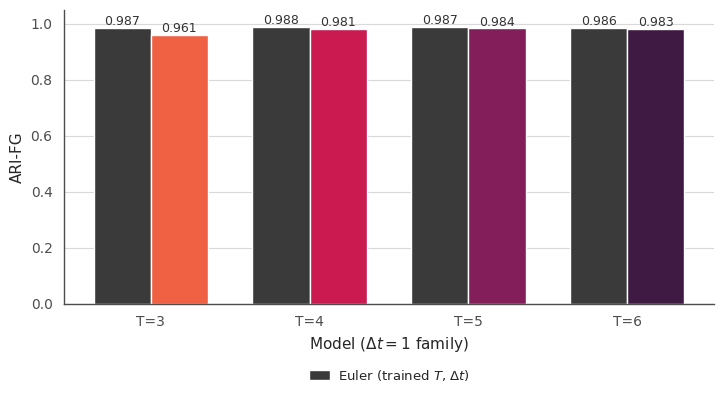

In [52]:
# Bar chart: Euler vs Dopri5 ARI-FG per dt=1 model.
sns.set_theme(style="white", context="paper", font_scale=1.25)

models = COMPARE_MODELS
x = np.arange(len(models))
bar_w = 0.36

eu_color = "#3a3a3a"   # deep gray
dp_color = "#4a2b6b"   # deep violet

def vals(metric, solver):
    return np.array([
        cmp_df[(cmp_df["model"] == m) & (cmp_df["solver"] == solver)][metric].iloc[0]
        for m in models
    ])

ari_eu = vals("ari_fg", "Euler")
ari_dp = vals("ari_fg", "Dopri5")

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.bar(x - bar_w/2, ari_eu, bar_w,
         color=eu_color, edgecolor="white", linewidth=1.0,                                                                                                                                                                                            label="Euler (trained $T$, $\\Delta t$)")
ax.bar(x + bar_w/2, ari_dp, bar_w,                                                                                                                                                                                                                  color=[T_COLORS[m] for m in models],
         edgecolor="white", linewidth=1.0)

for i, (eu, dp) in enumerate(zip(ari_eu, ari_dp)):
    ax.text(i - bar_w/2, eu, f"{eu:.3f}", ha="center", va="bottom", fontsize=9, color="0.2")
    ax.text(i + bar_w/2, dp, f"{dp:.3f}", ha="center", va="bottom", fontsize=9, color="0.2")

ax.set_xticks(x)
ax.set_xticklabels([m.split()[0] for m in models])
ax.set_xlabel("Model ($\\Delta t = 1$ family)", fontsize=11)
ax.set_ylabel("ARI-FG", fontsize=11)
ax.set_ylim(0, 1.05)

# Legend in the empty space below the plot, sitting to the right of the x-axis label.
ax.legend(fontsize=9.5,
            loc="upper center", bbox_to_anchor=(0.5, -0.20),                                                                                                                                                                                             ncol=2, frameon=False, handlelength=1.6,
            handletextpad=0.6, columnspacing=1.4, borderaxespad=0.0)

for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
ax.spines["left"].set_color("0.3"); ax.spines["bottom"].set_color("0.3")
ax.tick_params(axis="both", colors="0.3", labelsize=10)
ax.yaxis.grid(True, color="0.85", linewidth=0.8); ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("thesis_draft/figures/adaptive_compute_solver_arifg.png", dpi=220, bbox_inches="tight")
plt.show()